In [1]:
# ЦЕЛЬ:
# Разработать и реализовать собственный проект регрессии, начиная 
# с оформления задачи и сбора данных до построения модели и анализа
# её качества.


# Что нужно сделать:
# 01 Придумайте и сформулируйте свою задачу регрессии (например,
# предсказание цен на жилье, оценка производительности работы и
# т.д.).
# 02 Определите, какие признаки вы будете использовать и откуда
# возьмете данные.
# 03 Осуществите сбор данных (можно использовать API, вебскрейпинг или открытые источники).
# 04 Реализуйте модель регрессии, используя собранные данные,  и оцените её качество, применив метрики, которые вы изучили.
# 05 Сделайте выводы о том, насколько хорошо ваша модель
# предсказывает целевую переменную.


In [2]:
# Проект регрессии: Предсказание стоимости квартиы
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import pandas as pd

import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv('moscow_flat_data.csv')

In [4]:
data.head()

,Price,Apartment type,Metro station,Minutes to metro,Region,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Renovation
0,6300000.0,Secondary,Опалиха,6.0,Moscow region,1.0,30.6,11.1,8.5,25.0,25,Cosmetic
1,9000000.0,Secondary,Павшино,2.0,Moscow region,1.0,49.2,20.0,10.0,6.0,15,European-style renovation
2,11090000.0,Secondary,Мякинино,14.0,Moscow region,1.0,44.7,16.2,13.1,10.0,25,Cosmetic
3,8300000.0,Secondary,Строгино,8.0,Moscow region,1.0,35.1,16.0,11.0,12.0,33,European-style renovation
4,6450000.0,Secondary,Опалиха,6.0,Moscow region,1.0,37.7,15.2,4.0,5.0,5,Without renovation


In [5]:
# Предварительная обработка данных
X_pridictiion_graph = data[['Price', 'Area']]
X_intermediate = data.drop(columns=['Price'], axis=1)


In [6]:
X_pridictiion_graph

,Price,Area
0,6300000.0,30.60
1,9000000.0,49.20
2,11090000.0,44.70
3,8300000.0,35.10
4,6450000.0,37.70
...,...,...
22671,4768792.0,31.75
22672,5900000.0,31.60
22673,3700000.0,18.00
22674,5768869.0,36.39


In [7]:
X_intermediate

,Apartment type,Metro station,Minutes to metro,Region,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Renovation
0,Secondary,Опалиха,6.0,Moscow region,1.0,30.60,11.1,8.5,25.0,25,Cosmetic
1,Secondary,Павшино,2.0,Moscow region,1.0,49.20,20.0,10.0,6.0,15,European-style renovation
2,Secondary,Мякинино,14.0,Moscow region,1.0,44.70,16.2,13.1,10.0,25,Cosmetic
3,Secondary,Строгино,8.0,Moscow region,1.0,35.10,16.0,11.0,12.0,33,European-style renovation
4,Secondary,Опалиха,6.0,Moscow region,1.0,37.70,15.2,4.0,5.0,5,Without renovation
...,...,...,...,...,...,...,...,...,...,...,...
22671,New building,Котельники,8.0,Moscow region,0.0,31.75,13.0,5.0,4.0,17,Cosmetic
22672,New building,Домодедовская,25.0,Moscow region,1.0,31.60,10.1,12.2,11.0,15,Cosmetic
22673,New building,Котельники,30.0,Moscow region,0.0,18.00,15.0,8.1,17.0,17,Cosmetic
22674,New building,Жулебино,14.0,Moscow region,2.0,36.39,22.0,6.6,12.0,14,Cosmetic


In [19]:
X = data[['Area']]
y = data['Price']

In [20]:
X

,Area
0,30.60
1,49.20
2,44.70
3,35.10
4,37.70
...,...
22671,31.75
22672,31.60
22673,18.00
22674,36.39


In [21]:
y

0         6300000.0
1         9000000.0
2        11090000.0
3         8300000.0
4         6450000.0
            ...    
22671     4768792.0
22672     5900000.0
22673     3700000.0
22674     5768869.0
22675     6839157.0
Name: Price, Length: 22676, dtype: float64

In [22]:
# Разделим данные на тренировочные и тестовые
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [23]:
# Создание и обучение модели
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [27]:
# Прогнозируем значения на тестовом наборе
y_pred = model.predict(X_test)

In [29]:
# Оцениваем качество модели
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [30]:
print(f'Среднеквадратичная ошибка (MSE): {mse}')
print(f'Средняя абсолютная ошибка (MAE): {mae}')
print(f'Коэффициент детерминации R²: {r2}')

Среднеквадратичная ошибка (MSE): 2599670968695149.5
Средняя абсолютная ошибка (MAE): 22687602.861151718
Коэффициент детерминации R²: 0.607691437067047


In [31]:
# - Коэффициент детерминации R2 показывает, насколько модель объясняет разброс цен. Значение выше 0.7 считается хорошим результатом.
# - MAE отражает среднюю ошибку в рублях — чем меньше, тем точнее модель.
# - MSE чувствителен к большим ошибкам, помогает выявить выбросы.

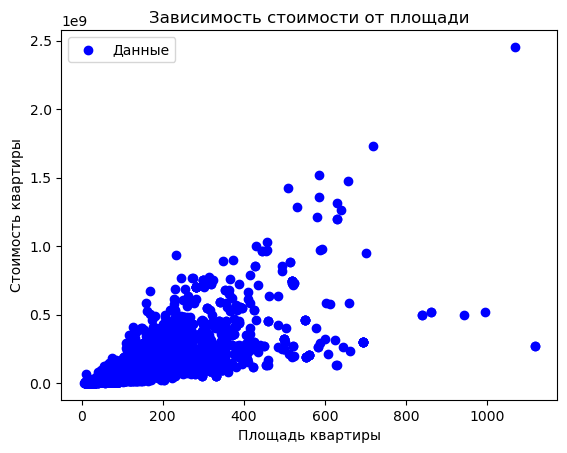

In [32]:
plt.scatter(X, y, color='blue', label='Данные')
plt.title('Зависимость стоимости от площади')
plt.xlabel('Площадь квартиры')
plt.ylabel('Стоимость квартиры')
plt.legend()
plt.show()

In [33]:
# X_intermediate_test = X_test.drop(columns=['Price'], axis=1)
# X = X_intermediate_test['Area']
X_test


,Area
11791,15.30
5345,38.50
12704,26.00
17086,67.20
217,72.20
...,...
2753,74.60
11458,14.30
3335,126.70
14725,57.60


In [34]:
# y_pred_main = model.predict(X_pridictiion_graph)
#  X_test
y_pred_test = model.predict(X_test)

In [35]:
y_pred_test

array([-18749030.30325787,   3709391.87569394,  -8391051.1086551 , ...,
        89090117.57326072,  22198868.75577926,   5006559.36361615])

In [36]:
X_test.size

4536

In [37]:
X_test

,Area
11791,15.30
5345,38.50
12704,26.00
17086,67.20
217,72.20
...,...
2753,74.60
11458,14.30
3335,126.70
14725,57.60


In [38]:
y_test.size

4536

In [39]:
y_test

11791      4200000.0
5345      10600000.0
12704     16000000.0
17086     12364800.0
217       16400000.0
            ...     
2753      33999999.0
11458     11800000.0
3335     171045000.0
14725     10482800.0
22417      5752184.0
Name: Price, Length: 4536, dtype: float64

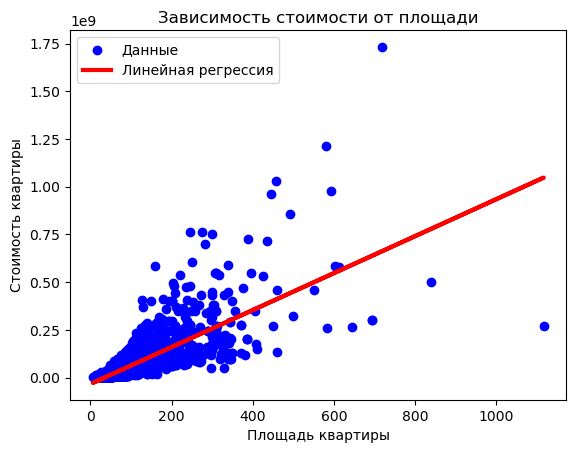

In [41]:
plt.scatter(X_test, y_test, color='blue', label='Данные')
plt.title('Зависимость стоимости от площади')
plt.plot(X_test, y_pred_test, color='red', linewidth=3, label='Линейная регрессия')
plt.xlabel('Площадь квартиры')
plt.ylabel('Стоимость квартиры')
plt.legend()
plt.show()

In [ ]:
# Ответы на вопросы: 
# 01 Придумайте и сформулируйте свою задачу регрессии - предсказание цен на жилье в Москве в зависимости от размера площади квартиры

# 02 Определите, какие признаки вы будете использовать и откуда
# возьмете данные.
# Берем файл moscow_flat_data.csv с сайта https://www.kaggle.com/datasets/egorkainov/moscow-housing-price-dataset
# Файл содержит следующие даннные/поля в таблице: Цена, Тип квартиры, Ближайшее метро, Время до метро, Регион, Кол-во комнат,
# Площадь, Жилая пллощадь, Площадь кухни, Кол-во этажей, Ремонт.
# Для поостроения модели регрессии выберем цену и площабь квартиры, Определим зависимость цены от площади квартиры

# 03 Осуществите сбор данных (можно использовать API, вебскрейпинг или открытые источники).
# Сбор данных осущекствляется с сайта https://www.kaggle.com/datasets/egorkainov/moscow-housing-price-dataset, файл moscow_flat_data.csv
#

# 04 Реализуйте модель регрессии, используя собранные данные,  и оцените её качество, применив метрики, которые вы изучили.
# Используются метрики: MSE, MAE, R²
# Значения метрик
# Среднеквадратичная ошибка (MSE): 2599670968695149.5
# Средняя абсолютная ошибка (MAE): 22687602.861151718
# Коэффициент детерминации R²: 0.607691437067047
#

# 05 Сделайте выводы о том, насколько хорошо ваша модель предсказывает целевую переменную.
# Метрик говорят, что:
# - R² - насколько хорошо модель описывает изменения данных, значениек 0.6 говори о том, что некая зависимость есть, можно 
# спрогнохировать с помощью регресии, но все же несовсем точно. Есть порог отсечения для коэфицента, который говорит, что прогнозирование
# корректне, данный порог 0.7, наше значение значительно ниже.
# - MSE, Среднеквадратичная ошибка - это значенние, которое показывает среднее значение квадратов 
# разностей между прогнозированием и фактическим значением. Значение 2599670968695149.5 оогромно, 
# что говорит об огроомном разбросе значение, а значит существуют еще параметры от которых зависит цена на квартиру и модель
# линейной регресии недостаточна
#
# - MAE, Средняя абсолютная ошибка - это среднее абсолютное отклонение между фактическими и прогнозируемыми значениями, 
# позволяет исключить выброосы значений. Но значение довольно большое, чт лишний раз доказывает, что завимоость цены от площади есть
# но не только, здесь сложная зависимость отнескольких параметров и линейная регрессия не может быть применена, если только
# не выделить данные, исключив часть записей, которые зависят от других параметров

In [ ]:
#Во вложении код в формате ipynb, транслированный в py, а также снимки экранов c кодом

# Ответы на вопросы:
# 01 Придумайте и сформулируйте свою задачу регрессии - предсказание цен на жилье в Москве в зависимости от размера площади квартиры

# 02 Определите, какие признаки вы будете использовать и откуда
# возьмете данные.
# Берем файл moscow_flat_data.csv с сайта https://www.kaggle.com/datasets/egorkainov/moscow-housing-price-dataset
# Файл содержит следующие данные/поля в таблице: Цена, Тип квартиры, Ближайшее метро, Время до метро, Регион, Кол-во комнат,
# Площадь, Жилая площадь, Площадь кухни, Кол-во этажей, Ремонт.
# Для построения модели регрессии выберем цену и площадь квартиры, Определим зависимость цены от площади квартиры

# 03 Осуществите сбор данных (можно использовать API, веб скрейпинг или открытые источники).
# Сбор данных осуществляется с сайта https://www.kaggle.com/datasets/egorkainov/moscow-housing-price-dataset, файл moscow_flat_data.csv
#

# 04 Реализуйте модель регрессии, используя собранные данные, и оцените её качество, применив метрики, которые вы изучили.
# Используются метрики: MSE, MAE, R²
# Значения метрик
# Среднеквадратичная ошибка (MSE): 2599670968695149.5
# Средняя абсолютная ошибка (MAE): 22687602.861151718
# Коэффициент детерминации R²: 0.607691437067047
#

# 05 Сделайте выводы о том, насколько хорошо ваша модель предсказывает целевую переменную.
# Метрик говорят, что:
# - R² - насколько хорошо модель описывает изменения данных, значение 0.6 говори о том, что некая зависимость есть, можно
# спрогнозировать с помощью регрессии, но все же не совсем точно. Есть порог отсечения для коэффицента, который говорит, что прогнозирование
# корректнее, данный порог 0.7, наше значение значительно ниже.
# - MSE, Среднеквадратичная ошибка - это значение, которое показывает среднее значение квадратов
# разностей между прогнозированием и фактическим значением. Значение 2599670968695149.5 огромно,
# что говорит об огромном разбросе значение, а значит существуют еще параметры от которых зависит цена на квартиру и модель
# линейной регрессии недостаточна
#
# - MAE, Средняя абсолютная ошибка - это среднее абсолютное отклонение между фактическими и прогнозируемыми значениями,
# позволяет исключить выбросы значений. Но значение довольно большое, что лишний раз доказывает, что зависимость цены от площади есть
# но не только, здесь сложная зависимость от нескольких параметров и линейная регрессия не может быть применена, если только
# не выделить данные, исключив часть записей, которые зависят от других параметров